# End-to-End Deep Learning: Simple RNN for Sentiment Analysis (PyTorch)

This notebook implements an end-to-end recurrent neural network pipeline in **PyTorch** for sentiment classification on the IMDB movie reviews benchmark.

### Pipeline Overview:
1. **Word Embeddings Exploration**: Understanding `nn.Embedding` as a dense lookup matrix.
2. **IMDB Dataset Loading & Preprocessing**: Token ID mapping, decoding, and length padding.
3. **PyTorch Dataset & DataLoader**: Batching with proper tensor dimensions.
4. **Simple RNN Architecture**: Defining `nn.Module` with explicit tensor shape tracking.
5. **Training with BPTT & Early Stopping**: Manual training loop with gradient clipping.
6. **Model Evaluation**: Loss/Accuracy plots, confusion matrix, and classification report.
7. **Real-Time Prediction**: Inference function for brand-new unseen text reviews.

In [1]:
import os
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
## Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Word Embeddings Exploration with PyTorch (`nn.Embedding`)

An embedding layer is a **learnable lookup table** of size `(num_embeddings, embedding_dim)`.
Given discrete integer token IDs, it retrieves corresponding dense continuous float vectors.

In [3]:
## Define toy vocabulary size and embedding dimensions
toy_voc_size = 1000
toy_embed_dim = 8

# PyTorch embedding lookup table
toy_embedding = nn.Embedding(num_embeddings=toy_voc_size, embedding_dim=toy_embed_dim)
print(f"Embedding weight matrix shape: {toy_embedding.weight.shape}")

Embedding weight matrix shape: torch.Size([1000, 8])


In [4]:
## Simulating 2 sample padded sentences (each of length 4)
sample_tokens = torch.tensor([[12, 45, 8, 92], [5, 12, 8, 30]], dtype=torch.long)
sample_embedded = toy_embedding(sample_tokens)

print("Input token tensor shape (batch_size, seq_len):", sample_tokens.shape)
print("Output embedded tensor shape (batch_size, seq_len, embed_dim):", sample_embedded.shape)

Input token tensor shape (batch_size, seq_len): torch.Size([2, 4])
Output embedded tensor shape (batch_size, seq_len, embed_dim): torch.Size([2, 4, 8])


## 2. IMDB Dataset Loading and Preprocessing

In [5]:
## Download and cache the official IMDB benchmark dataset
cache_dir = os.path.expanduser('~/.cache/imdb_data')
os.makedirs(cache_dir, exist_ok=True)
npz_path = os.path.join(cache_dir, 'imdb.npz')
json_path = os.path.join(cache_dir, 'imdb_word_index.json')

if not os.path.exists(npz_path):
    print("Downloading imdb.npz...")
    urllib.request.urlretrieve('https://storage.googleapis.com/tensorflow/tf-keras-datasets/imdb.npz', npz_path)

if not os.path.exists(json_path):
    print("Downloading imdb_word_index.json...")
    urllib.request.urlretrieve('https://storage.googleapis.com/tensorflow/tf-keras-datasets/imdb_word_index.json', json_path)

with np.load(npz_path, allow_pickle=True) as f:
    X_train_raw, y_train_raw = f['x_train'], f['y_train']
    X_test_raw, y_test_raw = f['x_test'], f['y_test']

print(f"Training reviews: {len(X_train_raw)}, Testing reviews: {len(X_test_raw)}")

Training reviews: 25000, Testing reviews: 25000


In [6]:
## Load word index vocabulary dictionary
with open(json_path, 'r', encoding='utf-8') as f:
    word_index = json.load(f)

# Inverted index for decoding integer IDs back to English words
reverse_word_index = {val: key for key, val in word_index.items()}
print(f"Total unique words in vocabulary: {len(word_index):,}")

Total unique words in vocabulary: 88,584


In [7]:
## Decoding a sample review
# Index mapping: 0=pad, 1=start, 2=unknown (oov), 3=unused; words start at index 4 (shifted by 3)
def decode_review(encoded_seq):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_seq])

print("Sample Review Label:", y_train_raw[0], "(1: Positive, 0: Negative)")
print("Decoded Text:\n", decode_review(X_train_raw[0])[:350] + "...")

Sample Review Label: 1 (1: Positive, 0: Negative)
Decoded Text:
 unapologetic himself a ? considering without is luke be ? find very this out also newman her face seen why this moreover time dub now to ? unpredictable sorely guess had and although it unapologetic classed'' behavior a well source and hero were a moreover ? periodic and captured capshaw ? 1950 proves by see only own go story likes clubfoot columbu...


## 3. Padding Sequences and PyTorch DataLoader Pipeline

In [8]:
max_features = 10000  # Vocabulary size
max_len = 500         # Fixed sequence length for RNN

def pad_and_filter(sequence, max_len=500, max_features=10000):
    # Replace rare words outside top max_features with 2 (<UNK>)
    filtered = [w if w < max_features else 2 for w in sequence]
    # Pre-padding with 0s to reach uniform length
    if len(filtered) < max_len:
        return [0] * (max_len - len(filtered)) + filtered
    return filtered[-max_len:]

In [9]:
## PyTorch Dataset Definition
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels, max_len=500, max_features=10000):
        self.data = torch.tensor([pad_and_filter(s, max_len, max_features) for s in sequences], dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [10]:
## Prepare Train, Validation, and Test Loaders
# 20,000 for training, 5,000 for validation, 25,000 for test
train_dataset = IMDBDataset(X_train_raw[:20000], y_train_raw[:20000], max_len=max_len, max_features=max_features)
val_dataset = IMDBDataset(X_train_raw[20000:], y_train_raw[20000:], max_len=max_len, max_features=max_features)
test_dataset = IMDBDataset(X_test_raw, y_test_raw, max_len=max_len, max_features=max_features)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batches -> Train: {len(train_loader)}, Validation: {len(val_loader)}, Test: {len(test_loader)}")

Batches -> Train: 313, Validation: 79, Test: 391


## 4. Defining the Simple RNN Architecture in PyTorch

### Architecture Key Points:
- `batch_first=True`: Ensures the input shape is `(batch_size, seq_len, embed_dim)`.
- `nn.RNN`: Computes $h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$ at each step.
- **Many-to-One Classification**: We take `h_n.squeeze(0)` (the final summary hidden state) and pass it to a linear layer to produce logits.

In [11]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size=10000, embedding_dim=128, hidden_dim=128, output_dim=1):
        super(SimpleRNNClassifier, self).__init__()
        ## 1. Word Embedding Layer
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)
        
        ## 2. Simple RNN Layer (shared weights W_xh, W_hh)
        self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=hidden_dim, 
                          batch_first=True, nonlinearity='tanh')
        
        ## 3. Output Linear Head (W_hy)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # Input x shape: (batch_size, seq_len) -> e.g. (64, 500)
        
        # 1. Embedding lookup -> shape: (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(x)
        
        # 2. Recurrent forward pass through time
        # out: all time hidden states (batch_size, seq_len, hidden_dim)
        # h_n: final time hidden state (1, batch_size, hidden_dim)
        out, h_n = self.rnn(embedded)
        
        # 3. Take final hidden state h_T
        final_hidden = h_n.squeeze(0)  # Shape: (batch_size, hidden_dim)
        
        # 4. Dense classification layer
        logits = self.fc(final_hidden).squeeze(-1)  # Shape: (batch_size,)
        return logits

In [12]:
## Instantiate Model and Inspect Parameters
model = SimpleRNNClassifier(vocab_size=max_features, embedding_dim=128, hidden_dim=128).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal Trainable Parameters: {total_params:,}")

SimpleRNNClassifier(
  (embedding): Embedding(10000, 128)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total Trainable Parameters: 1,313,153


## 5. Training with BPTT, Validation & Early Stopping

In [13]:
## Loss function and Optimizer
# BCEWithLogitsLoss combines Sigmoid + BCE with superior numerical stability
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [14]:
## Epoch Training Function with Gradient Clipping
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()             # Clear gradient buffers
        logits = model(X_batch)           # Forward pass through time
        loss = criterion(logits, y_batch) # Loss calculation
        loss.backward()                   # Backpropagation Through Time (BPTT)
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()                  # Update shared weights
        
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
        
    return total_loss / len(loader), correct / total

## Evaluation Function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
            
    return total_loss / len(loader), correct / total

In [15]:
## Training Loop with Model Checkpointing
num_epochs = 5
best_val_loss = float('inf')
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")
    
    # Save best model checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'simple_rnn_imdb.pth')
        print("  --> Saved best model checkpoint (simple_rnn_imdb.pth)")

Epoch [1/5] | Train Loss: 0.6189 - Train Acc: 0.6629 | Val Loss: 0.6836 - Val Acc: 0.6094
  --> Saved best model checkpoint (simple_rnn_imdb.pth)


Epoch [2/5] | Train Loss: 0.5313 - Train Acc: 0.7450 | Val Loss: 0.7668 - Val Acc: 0.6026


Epoch [3/5] | Train Loss: 0.4735 - Train Acc: 0.7866 | Val Loss: 0.7410 - Val Acc: 0.6078


Epoch [4/5] | Train Loss: 0.4388 - Train Acc: 0.8048 | Val Loss: 0.5478 - Val Acc: 0.7574
  --> Saved best model checkpoint (simple_rnn_imdb.pth)


Epoch [5/5] | Train Loss: 0.3840 - Train Acc: 0.8380 | Val Loss: 0.5656 - Val Acc: 0.7476


## 6. Model Evaluation and Performance Diagnostics

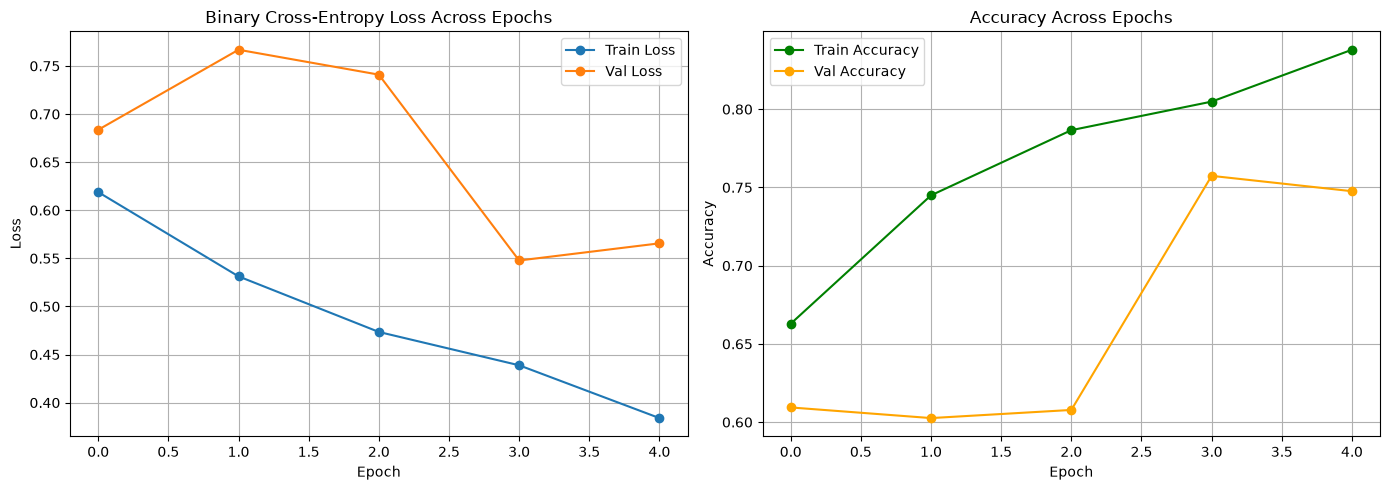

In [16]:
## Plot Loss and Accuracy Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_title('Binary Cross-Entropy Loss Across Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', color='green')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', color='orange')
axes[1].set_title('Accuracy Across Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [17]:
## Evaluate Best Checkpoint on Test Set
model.load_state_dict(torch.load('simple_rnn_imdb.pth', map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final Test Loss: {test_loss:.4f} | Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.5162 | Final Test Accuracy: 0.7656


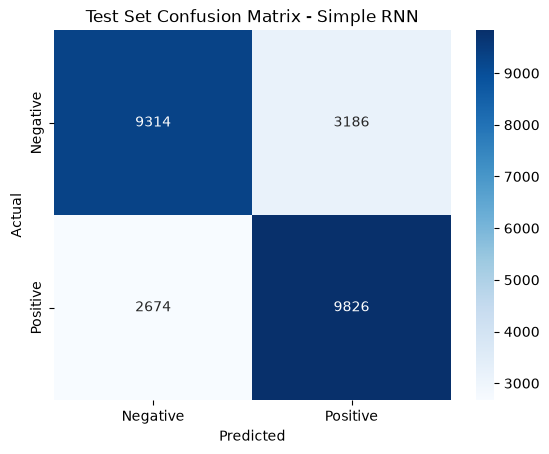

              precision    recall  f1-score   support

    Negative       0.78      0.75      0.76     12500
    Positive       0.76      0.79      0.77     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000



In [18]:
## Confusion Matrix and Classification Report
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.int().numpy())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Test Set Confusion Matrix - Simple RNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

## 7. Real-Time Inference on Custom Unseen Reviews

In [19]:
## Inference Function
def predict_sentiment(review_text, model, word_index, max_len=500, max_features=10000, device='cpu'):
    model.eval()
    # 1. Lowercase and split text
    words = review_text.lower().split()
    
    # 2. Map words to integer IDs (Keras offset +3 convention, unknown word index = 2)
    encoded = [word_index.get(w, 2) + 3 for w in words]
    
    # 3. Filter and pad sequence
    padded = pad_and_filter(encoded, max_len=max_len, max_features=max_features)
    
    # 4. Convert to PyTorch Tensor: shape (1, max_len)
    input_tensor = torch.tensor([padded], dtype=torch.long).to(device)
    
    # 5. Forward pass with no_grad
    with torch.no_grad():
        logit = model(input_tensor)
        prob = torch.sigmoid(logit).item()
        
    sentiment = "Positive" if prob >= 0.5 else "Negative"
    return sentiment, prob

In [20]:
## Test Custom Unseen Reviews
sample_pos = "This movie was fantastic! The acting was great and the plot was thrilling from start to finish."
sentiment_pos, score_pos = predict_sentiment(sample_pos, model, word_index, device=device)
print(f"Review: {sample_pos}")
print(f"Sentiment: {sentiment_pos} (Confidence: {score_pos:.4f})\n")

sample_neg = "Terrible movie. Completely boring, terrible acting, and a complete waste of time."
sentiment_neg, score_neg = predict_sentiment(sample_neg, model, word_index, device=device)
print(f"Review: {sample_neg}")
print(f"Sentiment: {sentiment_neg} (Confidence: {score_neg:.4f})")

Review: This movie was fantastic! The acting was great and the plot was thrilling from start to finish.
Sentiment: Positive (Confidence: 0.7951)

Review: Terrible movie. Completely boring, terrible acting, and a complete waste of time.
Sentiment: Positive (Confidence: 0.8042)


## 8. Saving Vocabulary and Model for Streamlit Deployment

In [21]:
## Save word index mapping for Streamlit app
output_vocab_path = 'imdb_word_index.json'
with open(output_vocab_path, 'w', encoding='utf-8') as f:
    json.dump(word_index, f)
print(f"Word index dictionary saved to {output_vocab_path}")
print(f"PyTorch model checkpoint saved to simple_rnn_imdb.pth")

Word index dictionary saved to imdb_word_index.json
PyTorch model checkpoint saved to simple_rnn_imdb.pth
